# 07 — Markowitz Efficient Frontier (Bonus B4)
Portfolio optimization across 5 selected funds using Modern Portfolio Theory: computes the efficient frontier, the minimum-variance portfolio, and the maximum-Sharpe (tangency) portfolio.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pathlib import Path

RAW_DIR = Path("../data/raw")

fund_master = pd.read_csv(RAW_DIR / "01_fund_master.csv")
nav_history = pd.read_csv(RAW_DIR / "02_nav_history.csv", parse_dates=["date"])
scheme_perf = pd.read_csv(RAW_DIR / "07_scheme_performance.csv")

nav_history = nav_history.sort_values(["amfi_code", "date"])
scheme_names = fund_master.set_index("amfi_code")["scheme_name"].to_dict()

RISK_FREE_ANNUAL = 0.06

## Select 5 funds
Top 5 funds by AUM, spanning a mix of categories/risk grades for a meaningful diversification story.

In [2]:
selected = scheme_perf.sort_values("aum_crore", ascending=False).head(5)["amfi_code"].tolist()

print("Selected funds:")
for code_ in selected:
    grade = scheme_perf.loc[scheme_perf["amfi_code"] == code_, "risk_grade"].values[0]
    print(f" - {scheme_names.get(code_, code_):<45} risk_grade={grade}")

Selected funds:
 - Mirae Asset Emerging Bluechip Fund - Regular - Growth risk_grade=Moderately High
 - Kotak Emerging Equity Fund - Regular - Growth risk_grade=High
 - Nippon India Small Cap Fund - Regular - Growth risk_grade=Very High
 - DSP Top 100 Equity Fund - Regular - Growth    risk_grade=Moderate
 - UTI Mid Cap Fund - Regular - Growth           risk_grade=High


## Build the returns matrix
Pivot daily returns into a wide matrix (dates x funds), aligned on common dates.

In [3]:
nav_wide = nav_history[nav_history["amfi_code"].isin(selected)].pivot(
    index="date", columns="amfi_code", values="nav"
).sort_index()

returns_wide = nav_wide.pct_change().dropna()
returns_wide.columns = [scheme_names.get(c, c)[:30] for c in returns_wide.columns]

mean_daily_returns = returns_wide.mean()
cov_daily = returns_wide.cov()

mean_annual_returns = mean_daily_returns * 252
cov_annual = cov_daily * 252

print("Annualized expected returns:")
print((mean_annual_returns * 100).round(2).astype(str) + "%")

Annualized expected returns:
UTI Mid Cap Fund - Regular - G     2.77%
Nippon India Small Cap Fund -     17.82%
Kotak Emerging Equity Fund - R     7.86%
Mirae Asset Emerging Bluechip     20.79%
DSP Top 100 Equity Fund - Regu    13.16%
dtype: str


## Portfolio math helpers

In [4]:
n_assets = len(selected)

def portfolio_perf(weights, mean_returns, cov_matrix):
    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (ret - RISK_FREE_ANNUAL) / vol
    return ret, vol, sharpe

def neg_sharpe(weights, mean_returns, cov_matrix):
    return -portfolio_perf(weights, mean_returns, cov_matrix)[2]

def portfolio_vol(weights, mean_returns, cov_matrix):
    return portfolio_perf(weights, mean_returns, cov_matrix)[1]

bounds = tuple((0.0, 1.0) for _ in range(n_assets))
constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
init_guess = np.array([1.0 / n_assets] * n_assets)

## Optimize: Max Sharpe and Minimum Variance portfolios

In [5]:
max_sharpe_result = minimize(
    neg_sharpe, init_guess, args=(mean_annual_returns.values, cov_annual.values),
    method="SLSQP", bounds=bounds, constraints=constraints,
)
min_vol_result = minimize(
    portfolio_vol, init_guess, args=(mean_annual_returns.values, cov_annual.values),
    method="SLSQP", bounds=bounds, constraints=constraints,
)

max_sharpe_weights = max_sharpe_result.x
min_vol_weights = min_vol_result.x

max_sharpe_ret, max_sharpe_vol, max_sharpe_sr = portfolio_perf(
    max_sharpe_weights, mean_annual_returns.values, cov_annual.values)
min_vol_ret, min_vol_vol, min_vol_sr = portfolio_perf(
    min_vol_weights, mean_annual_returns.values, cov_annual.values)

print("Max Sharpe portfolio:")
for name, w in zip(returns_wide.columns, max_sharpe_weights):
    print(f"  {name:<32} {w*100:5.1f}%")
print(f"  -> return={max_sharpe_ret*100:.2f}%  vol={max_sharpe_vol*100:.2f}%  sharpe={max_sharpe_sr:.2f}")

print("\nMin Variance portfolio:")
for name, w in zip(returns_wide.columns, min_vol_weights):
    print(f"  {name:<32} {w*100:5.1f}%")
print(f"  -> return={min_vol_ret*100:.2f}%  vol={min_vol_vol*100:.2f}%  sharpe={min_vol_sr:.2f}")

Max Sharpe portfolio:
  UTI Mid Cap Fund - Regular - G     0.0%
  Nippon India Small Cap Fund -     13.9%
  Kotak Emerging Equity Fund - R     6.8%
  Mirae Asset Emerging Bluechip     51.3%
  DSP Top 100 Equity Fund - Regu    28.0%
  -> return=17.37%  vol=9.77%  sharpe=1.16

Min Variance portfolio:
  UTI Mid Cap Fund - Regular - G    18.0%
  Nippon India Small Cap Fund -      9.2%
  Kotak Emerging Equity Fund - R    19.6%
  Mirae Asset Emerging Bluechip     25.4%
  DSP Top 100 Equity Fund - Regu    27.8%
  -> return=12.62%  vol=7.78%  sharpe=0.85


## Trace the efficient frontier
For a range of target returns, find the minimum-variance portfolio that achieves each target — tracing the frontier curve.

In [6]:
target_returns = np.linspace(mean_annual_returns.min(), mean_annual_returns.max(), 50)
frontier_vols = []

for target in target_returns:
    cons = (
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},
        {"type": "eq", "fun": lambda w, target=target: np.dot(w, mean_annual_returns.values) - target},
    )
    result = minimize(
        portfolio_vol, init_guess, args=(mean_annual_returns.values, cov_annual.values),
        method="SLSQP", bounds=bounds, constraints=cons,
    )
    frontier_vols.append(result.fun if result.success else np.nan)

frontier_df = pd.DataFrame({"return": target_returns, "volatility": frontier_vols}).dropna()
print(f"Frontier computed: {len(frontier_df)} points")

Frontier computed: 50 points


## Random portfolio cloud + frontier + optimal points

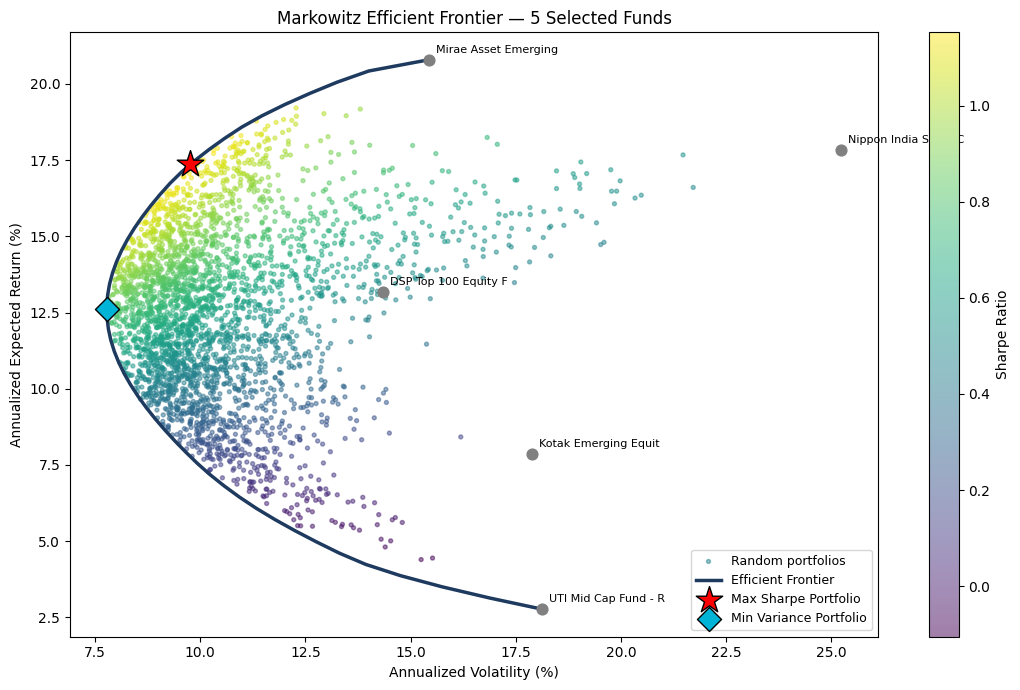

In [7]:
N_RANDOM = 3000
rand_weights = np.random.dirichlet(np.ones(n_assets), N_RANDOM)
rand_returns = rand_weights @ mean_annual_returns.values
rand_vols = np.sqrt(np.einsum('ij,jk,ik->i', rand_weights, cov_annual.values, rand_weights))
rand_sharpe = (rand_returns - RISK_FREE_ANNUAL) / rand_vols

plt.figure(figsize=(11, 7))
sc = plt.scatter(rand_vols * 100, rand_returns * 100, c=rand_sharpe, cmap="viridis",
                  s=8, alpha=0.5, label="Random portfolios")
plt.colorbar(sc, label="Sharpe Ratio")

plt.plot(frontier_df["volatility"] * 100, frontier_df["return"] * 100,
          color="#1E3A5F", linewidth=2.5, label="Efficient Frontier")

plt.scatter([max_sharpe_vol * 100], [max_sharpe_ret * 100], color="red", marker="*",
            s=400, label="Max Sharpe Portfolio", edgecolors="black", zorder=5)
plt.scatter([min_vol_vol * 100], [min_vol_ret * 100], color="#00B4D8", marker="D",
            s=150, label="Min Variance Portfolio", edgecolors="black", zorder=5)

for i, name in enumerate(returns_wide.columns):
    r = mean_annual_returns.values[i]
    v = np.sqrt(cov_annual.values[i, i])
    plt.scatter([v * 100], [r * 100], color="grey", marker="o", s=60, zorder=4)
    plt.annotate(name[:20], (v * 100, r * 100), fontsize=8, xytext=(5, 5), textcoords="offset points")

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Expected Return (%)")
plt.title("Markowitz Efficient Frontier — 5 Selected Funds")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("efficient_frontier.png", dpi=150)
plt.show()

## Save optimal portfolio weights

In [8]:
weights_df = pd.DataFrame({
    "scheme_name": returns_wide.columns,
    "max_sharpe_weight_pct": (max_sharpe_weights * 100).round(2),
    "min_variance_weight_pct": (min_vol_weights * 100).round(2),
})
weights_df.to_csv("efficient_frontier_weights.csv", index=False)
weights_df

,scheme_name,max_sharpe_weight_pct,min_variance_weight_pct
0,UTI Mid Cap Fund - Regular - G,0.00,17.99
1,Nippon India Small Cap Fund -,13.93,9.16
2,Kotak Emerging Equity Fund - R,6.78,19.57
3,Mirae Asset Emerging Bluechip,51.31,25.44
4,DSP Top 100 Equity Fund - Regu,27.98,27.84


**Interpretation:** the Max Sharpe portfolio maximizes risk-adjusted return (best return per unit of risk taken); the Min Variance portfolio minimizes volatility regardless of return. Any portfolio on the curve between them is efficient — no other combination of these 5 funds achieves higher return for the same risk.